# 01 — Data Preparation: Layer 2 (Macro Topic) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 2 — Macro Topic (`TOPIC_ECON`, `TOPIC_GOV`, `TOPIC_SERV`, `TOPIC_LAW`, `TOPIC_FOR`, `TOPIC_MEDIA`) |
| **Notebook role** | Data preparation, class imbalance mitigation, and feature engineering only — no model training happens here |
| **Owner** | Ahmed Aadhil |
| **Upstream input** | `data/golden_sample/golden_sample_labeled.csv` |
| **Downstream consumers** | `02_training.ipynb`, `03_evaluation.ipynb` |
| **Constraint** | This project uses the Golden Sample only — no supplementary data collection for this training round. Every technique in this notebook works within that constraint rather than around it. |
| **Random seed** | 42 (fixed throughout) |

## Purpose

Layer 2 has a real, documented class imbalance problem: `TOPIC_GOV` accounts for 82% of
valid comments, while `TOPIC_SERV` and `TOPIC_ECON` have well under 200 examples each.
This notebook applies two complementary, evidence-based mitigation techniques —
**capped oversampling** (a data-level fix, applied here) and **class weight computation**
(a training-level fix, computed here and consumed by `02_training.ipynb`) — and is
explicit throughout about what these techniques can and cannot fix given a fixed dataset.

## How to Read This Notebook

Written assuming no prior context. As in the Layer 1 notebooks, we do not target or claim
100% accuracy, and we do not claim the imbalance techniques below fully solve the data
scarcity for `TOPIC_SERV`/`TOPIC_ECON`/`TOPIC_FOR` — they meaningfully improve what the
model can learn from a fixed dataset, and the remaining limitation is stated plainly in
Section 9 rather than hidden.

**A note on "feature engineering" in this notebook:** XLM-RoBERTa is a pretrained
transformer that learns its own text representations directly from tokenized input — it
does not take hand-built features (TF-IDF vectors, n-gram counts, etc.) the way a
classical ML model would. What we engineer here instead are **diagnostic features**:
script composition, code-switching intensity, and emoji density — used to understand
*where* the model is likely to struggle across Sinhala/Singlish/English, and to make
principled decisions during stratified sampling. These are not fed into the model as
separate inputs; the tokenized `text_raw` is the only model input.

## 1. Setup & Configuration

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path("../../")  # this notebook lives in notebooks/07_layer2_topic/
GOLDEN_SAMPLE_PATH = PROJECT_ROOT / "data" / "golden_sample" / "golden_sample_labeled.csv"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer2"
MODEL_DIR = PROJECT_ROOT / "models" / "layer2_topic"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

UNRELIABLE_ANNOTATOR = "llm_groq_openai/gpt-oss-120b"

# Imbalance mitigation config -- documented, tunable, not hardcoded magic numbers
OVERSAMPLE_FLOOR = 400       # target ceiling for oversampling -- matches project's data-sufficiency floor
OVERSAMPLE_MAX_MULTIPLIER = 3  # never duplicate a class more than 3x its original size,
                                 # to limit memorization risk from repeated exact duplicates

print("Golden sample path:", GOLDEN_SAMPLE_PATH.resolve())

Golden sample path: C:\Users\ahdaa\Downloads\public-pulse-srilanka-main\public-pulse-srilanka-main\data\golden_sample\golden_sample_labeled.csv


## 2. Load the Golden Sample

In [2]:
df = pd.read_csv(GOLDEN_SAMPLE_PATH)
print("Raw golden sample shape:", df.shape)

Raw golden sample shape: (10000, 28)


## 3. Data Cleaning

Same two cleaning decisions established in the Layer 1 notebook, applied here for
consistency across the project (both are project-wide decisions, not Layer-1-specific).

In [3]:
before_n = len(df)
df_clean = df[df["annotator_id"] != UNRELIABLE_ANNOTATOR].copy()
print(f"Removed unreliable annotator batch: {before_n} -> {len(df_clean)} rows")

df_clean = df_clean.drop(columns=["layer3_subissue_label"])
print("Dropped layer3_subissue_label (project-wide scope decision).")

Removed unreliable annotator batch: 10000 -> 9290 rows
Dropped layer3_subissue_label (project-wide scope decision).


### 3.1 Filter to Layer 1 `VALID` Rows

Layer 2 is cascade-dependent on Layer 1: a comment only gets a topic if it was first
judged to be real content, not noise. We filter to `layer1_utility_label == "VALID"` here
— this is not a Layer-2-specific decision, it's how the taxonomy is structured.

In [4]:
valid_df = df_clean[df_clean["layer1_utility_label"] == "VALID"].copy()
print(f"Valid rows (Layer 2's actual population): {len(valid_df)} / {len(df_clean)}")

Valid rows (Layer 2's actual population): 7686 / 9290


### 3.2 Confirm `NULL` Has Zero Examples — Documented Finding

Layer 2's taxonomy includes `NULL` (a valid comment that doesn't fit any topic) as a
theoretically valid label. In practice, checking this Golden Sample directly:

In [5]:
null_count = valid_df["layer2_topic_label"].isna().sum()
print(f"Rows with blank/NULL layer2_topic_label: {null_count} / {len(valid_df)}")

if null_count == 0:
    print("\nFINDING: Zero NULL examples exist in this dataset. The model trained from "
          "this notebook's output cannot learn to predict NULL, because it has never "
          "seen an example of it. We exclude NULL from the trainable label set below "
          "and document this as a known limitation (see Section 9 and Handover Notes) "
          "rather than including an unlearnable class.")

Rows with blank/NULL layer2_topic_label: 0 / 7686

FINDING: Zero NULL examples exist in this dataset. The model trained from this notebook's output cannot learn to predict NULL, because it has never seen an example of it. We exclude NULL from the trainable label set below and document this as a known limitation (see Section 9 and Handover Notes) rather than including an unlearnable class.


## 4. Text Field Selection

Same decision and reasoning as `01_data_preparation.ipynb` for Layer 1: we use `text_raw`,
not `text_normalized`, since transformer fine-tuning doesn't benefit from aggressive
punctuation/casing normalization the way classical NLP pipelines do, and topic-relevant
proper nouns/capitalization (e.g. acronyms, named entities) are plausibly informative for
topic classification specifically.

In [6]:
identical = (valid_df["text_raw"] == valid_df["text_normalized"]).sum()
print(f"text_raw == text_normalized: {identical} / {len(valid_df)} ({identical/len(valid_df)*100:.1f}%)")
print("Decision: using text_raw as model input, consistent with the Layer 1 notebook.")

text_raw == text_normalized: 2056 / 7686 (26.7%)
Decision: using text_raw as model input, consistent with the Layer 1 notebook.


## 5. Feature Engineering — Script Composition & Code-Switching Diagnostics

As discussed in "How to Read This Notebook," these are **diagnostic features**, not model
inputs. They let us understand whether performance later correlates with how heavily a
comment code-switches — a genuinely useful signal for a low-resource, code-switched
language setting, even though the transformer itself never sees these features directly.

In [7]:
import re

SINHALA_RANGE = re.compile(r"[\u0D80-\u0DFF]")
LATIN_RANGE = re.compile(r"[A-Za-z]")

def script_composition(text):
    """Returns (sinhala_char_ratio, latin_char_ratio, is_code_switched) for a comment."""
    if not isinstance(text, str) or len(text) == 0:
        return 0.0, 0.0, False
    sinhala_chars = len(SINHALA_RANGE.findall(text))
    latin_chars = len(LATIN_RANGE.findall(text))
    total_letters = sinhala_chars + latin_chars
    if total_letters == 0:
        return 0.0, 0.0, False
    sinhala_ratio = sinhala_chars / total_letters
    latin_ratio = latin_chars / total_letters
    # "Code-switched" defined as meaningfully mixing both scripts, not just a stray character
    is_code_switched = (sinhala_ratio > 0.1) and (latin_ratio > 0.1)
    return round(sinhala_ratio, 3), round(latin_ratio, 3), is_code_switched

script_features = valid_df["text_raw"].apply(script_composition)
valid_df["sinhala_char_ratio"] = script_features.apply(lambda x: x[0])
valid_df["latin_char_ratio"] = script_features.apply(lambda x: x[1])
valid_df["is_code_switched"] = script_features.apply(lambda x: x[2])

valid_df["emoji_count"] = valid_df["emoji_list"].apply(
    lambda x: 0 if pd.isna(x) else len(str(x).split(","))
)

print("Code-switching rate across all valid comments:",
      f"{valid_df['is_code_switched'].mean()*100:.1f}%")
print()
print("Script composition summary:")
print(valid_df[["sinhala_char_ratio", "latin_char_ratio"]].describe())

Code-switching rate across all valid comments: 7.2%

Script composition summary:
       sinhala_char_ratio  latin_char_ratio
count         7686.000000       7686.000000
mean             0.523871          0.476129
std              0.484185          0.484185
min              0.000000          0.000000
25%              0.000000          0.000000
50%              0.812000          0.188000
75%              1.000000          1.000000
max              1.000000          1.000000


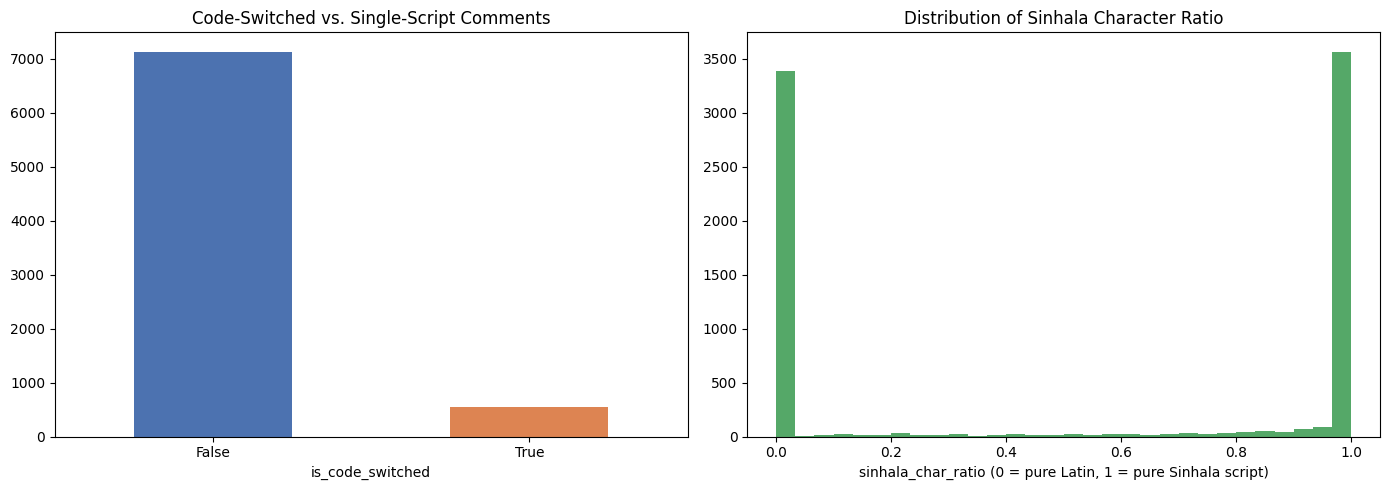

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_df["is_code_switched"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Code-Switched vs. Single-Script Comments")
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(valid_df["sinhala_char_ratio"], bins=30, color="#55A868")
axes[1].set_title("Distribution of Sinhala Character Ratio")
axes[1].set_xlabel("sinhala_char_ratio (0 = pure Latin, 1 = pure Sinhala script)")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer2_script_composition.png", dpi=150)
plt.show()

### 5.1 Does Code-Switching Rate Vary by Topic?

A genuinely useful diagnostic question: if certain topics are discussed more in
code-switched language than others, that's worth knowing before evaluation — it could
mean topic performance differences are partly a code-switching-difficulty effect, not
purely a data-volume effect.

Code-switching rate (%) by topic:
layer2_topic_label
TOPIC_SERV     14.7
TOPIC_MEDIA     9.2
TOPIC_GOV       7.4
TOPIC_FOR       5.6
TOPIC_LAW       3.3
TOPIC_ECON      2.6
Name: is_code_switched, dtype: float64


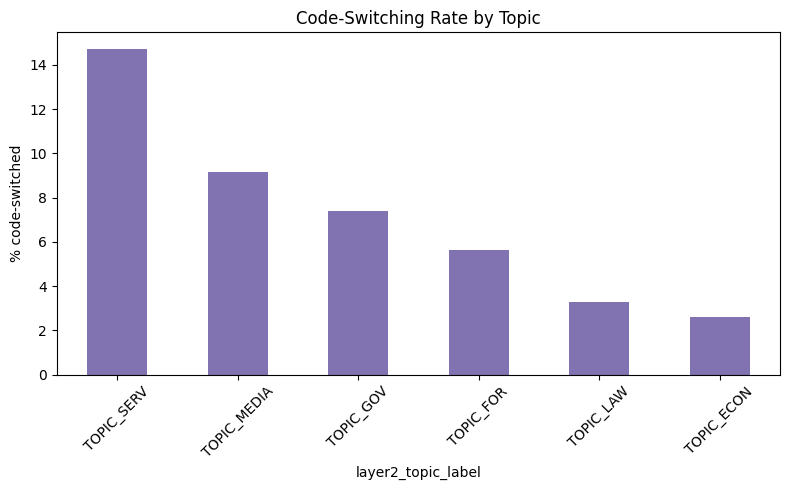

In [9]:
codeswitch_by_topic = valid_df.groupby("layer2_topic_label")["is_code_switched"].mean().sort_values(ascending=False) * 100
print("Code-switching rate (%) by topic:")
print(codeswitch_by_topic.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
codeswitch_by_topic.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Code-Switching Rate by Topic")
ax.set_ylabel("% code-switched")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer2_codeswitch_by_topic.png", dpi=150)
plt.show()

## 6. Layer 2 Target Variable Analysis

In [10]:
l2_counts = valid_df["layer2_topic_label"].value_counts()
l2_pct = valid_df["layer2_topic_label"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": l2_counts, "percent": l2_pct.round(1)})
print(summary)

                    count  percent
layer2_topic_label                
TOPIC_GOV            6333     82.4
TOPIC_LAW             457      5.9
TOPIC_MEDIA           382      5.0
TOPIC_FOR             266      3.5
TOPIC_ECON            153      2.0
TOPIC_SERV             95      1.2


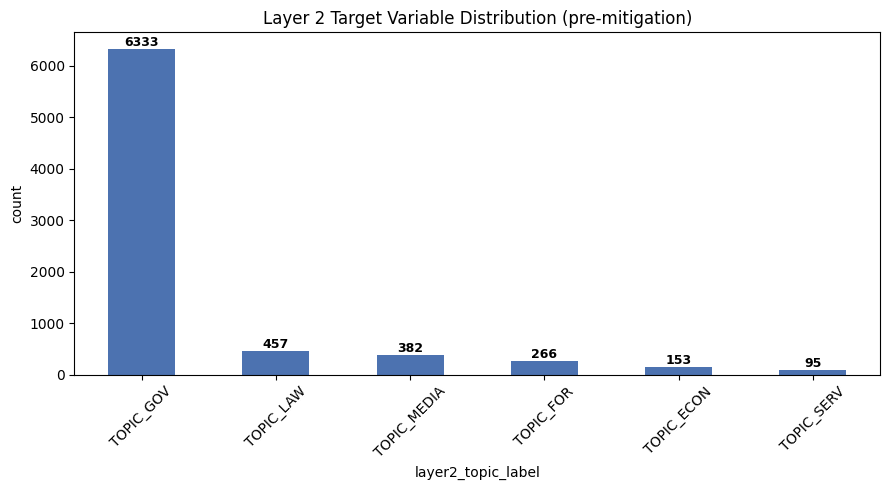

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
l2_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Layer 2 Target Variable Distribution (pre-mitigation)")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(l2_counts):
    ax.text(i, v + 60, str(v), ha="center", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer2_target_distribution_raw.png", dpi=150)
plt.show()

## 7. Class Balance Assessment

Against the project's documented thresholds for a moderate-difficulty task (topic
classification with lexical overlap): 400/class floor, 800/class for strong performance.

In [12]:
FLOOR = 400
TARGET = 800

assessment = pd.DataFrame({"count": l2_counts})
assessment["meets_floor"] = assessment["count"] >= FLOOR
assessment["meets_target"] = assessment["count"] >= TARGET
print(assessment)
print()
below_floor = assessment[~assessment["meets_floor"]].index.tolist()
print(f"Classes below floor: {below_floor}")
print("These are the classes Sections 8-9 specifically address.")

                    count  meets_floor  meets_target
layer2_topic_label                                  
TOPIC_GOV            6333         True          True
TOPIC_LAW             457         True         False
TOPIC_MEDIA           382        False         False
TOPIC_FOR             266        False         False
TOPIC_ECON            153        False         False
TOPIC_SERV             95        False         False

Classes below floor: ['TOPIC_MEDIA', 'TOPIC_FOR', 'TOPIC_ECON', 'TOPIC_SERV']
These are the classes Sections 8-9 specifically address.


## 8. Stratified Train / Validation / Test Split

**Critical ordering: split first, mitigate imbalance second.** Oversampling must only ever
touch the training set — applying it before splitting would let duplicated copies of the
same original comment leak across train/val/test, silently inflating validation/test
performance on minority classes without the model actually generalizing better. This is a
data leakage bug that would specifically hide the exact problem we're trying to solve, so
the order below is not incidental.

In [13]:
feature_cols = ["comment_id", "text_raw", "channel_name", "source_type", "language_detected",
                "sinhala_char_ratio", "latin_char_ratio", "is_code_switched", "emoji_count"]

X = valid_df[feature_cols]
y = valid_df["layer2_topic_label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

train_df = X_train.copy(); train_df["layer2_topic_label"] = y_train
val_df = X_val.copy(); val_df["layer2_topic_label"] = y_val
test_df = X_test.copy(); test_df["layer2_topic_label"] = y_test

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print()
print("Train class counts (pre-oversampling):")
print(train_df["layer2_topic_label"].value_counts())

Train: 5380  Val: 1153  Test: 1153

Train class counts (pre-oversampling):
layer2_topic_label
TOPIC_GOV      4433
TOPIC_LAW       320
TOPIC_MEDIA     267
TOPIC_FOR       186
TOPIC_ECON      107
TOPIC_SERV       67
Name: count, dtype: int64


## 9. Class Imbalance Mitigation

Two techniques, applied at different stages of the pipeline:

1. **Capped oversampling (this notebook, train set only):** minority classes are
   duplicated up to a target size, capped at both `OVERSAMPLE_FLOOR` (400) and
   `OVERSAMPLE_MAX_MULTIPLIER` (3x original size) — whichever is smaller. The multiplier
   cap exists specifically to prevent extreme duplication of a very small class (e.g.
   `TOPIC_SERV`) from causing the model to memorize a handful of exact comments rather
   than learn the general topic.
2. **Class weights (computed here, applied in `02_training.ipynb`'s loss function):**
   computed from the **original, pre-oversampling** train distribution, so the two
   techniques compose rather than double-correct for the same imbalance.

**Honest limitation, stated plainly:** even after both techniques, `TOPIC_SERV`
(95 total examples) cannot be raised to the 400-example floor within the 3x cap — it can
only reach ~285. This is an accepted, documented ceiling of what's achievable from the
Golden Sample alone, not a hidden shortfall. `TOPIC_ECON` and `TOPIC_FOR` fare better
(both reach the 400 floor) but still remain the weakest-supported classes relative to
`TOPIC_GOV`.

In [14]:
def compute_oversample_target(original_count, floor, max_multiplier):
    if original_count >= floor:
        return original_count  # already sufficient, no oversampling needed
    return min(floor, original_count * max_multiplier)

train_counts = train_df["layer2_topic_label"].value_counts()
oversample_plan = pd.DataFrame({"original_count": train_counts})
oversample_plan["target_count"] = oversample_plan["original_count"].apply(
    lambda n: compute_oversample_target(n, OVERSAMPLE_FLOOR, OVERSAMPLE_MAX_MULTIPLIER)
)
oversample_plan["reaches_floor"] = oversample_plan["target_count"] >= OVERSAMPLE_FLOOR
print(oversample_plan)

                    original_count  target_count  reaches_floor
layer2_topic_label                                             
TOPIC_GOV                     4433          4433           True
TOPIC_LAW                      320           400           True
TOPIC_MEDIA                    267           400           True
TOPIC_FOR                      186           400           True
TOPIC_ECON                     107           321          False
TOPIC_SERV                      67           201          False


In [15]:
oversampled_parts = [train_df]  # start with the original rows

for topic, row in oversample_plan.iterrows():
    original_n = row["original_count"]
    target_n = row["target_count"]
    additional_needed = int(target_n - original_n)
    if additional_needed > 0:
        pool = train_df[train_df["layer2_topic_label"] == topic]
        extra = pool.sample(n=additional_needed, replace=True, random_state=RANDOM_STATE)
        oversampled_parts.append(extra)

train_oversampled_df = pd.concat(oversampled_parts, ignore_index=True)
train_oversampled_df = train_oversampled_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Train set size before oversampling:", len(train_df))
print("Train set size after oversampling: ", len(train_oversampled_df))
print()
print("Class distribution after oversampling:")
print(train_oversampled_df["layer2_topic_label"].value_counts())

Train set size before oversampling: 5380
Train set size after oversampling:  6155

Class distribution after oversampling:
layer2_topic_label
TOPIC_GOV      4433
TOPIC_LAW       400
TOPIC_FOR       400
TOPIC_MEDIA     400
TOPIC_ECON      321
TOPIC_SERV      201
Name: count, dtype: int64


### 9.1 Compute Class Weights (from original, pre-oversampling distribution)

Saved separately for `02_training.ipynb` to load directly into a weighted loss function —
this notebook does not train anything, it only prepares what training needs.

In [16]:
topic_labels_sorted = sorted(train_df["layer2_topic_label"].unique())

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(topic_labels_sorted),
    y=train_df["layer2_topic_label"].values,  # ORIGINAL distribution, not oversampled
)
class_weights = dict(zip(topic_labels_sorted, class_weights_array.round(4)))

print("Computed class weights (higher = rarer class, weighted more in the loss):")
for label, weight in sorted(class_weights.items(), key=lambda x: -x[1]):
    print(f"  {label:15s} {weight}")

with open(MODEL_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)
print("\nSaved to:", MODEL_DIR / "class_weights.json")

Computed class weights (higher = rarer class, weighted more in the loss):
  TOPIC_SERV      13.3831
  TOPIC_ECON      8.3801
  TOPIC_FOR       4.8208
  TOPIC_MEDIA     3.3583
  TOPIC_LAW       2.8021
  TOPIC_GOV       0.2023

Saved to: ..\..\models\layer2_topic\class_weights.json


## 10. Data Quality Validation (Hard Assertions)

In [17]:
LAYER2_LABELS = ["TOPIC_ECON", "TOPIC_GOV", "TOPIC_SERV", "TOPIC_LAW", "TOPIC_FOR", "TOPIC_MEDIA"]

errors = []
for name, split_df in [("train_oversampled", train_oversampled_df), ("val", val_df), ("test", test_df)]:
    if split_df["layer2_topic_label"].isna().any():
        errors.append(f"{name}: missing labels found")
    invalid = set(split_df["layer2_topic_label"].unique()) - set(LAYER2_LABELS)
    if invalid:
        errors.append(f"{name}: unexpected label values {invalid}")

# val/test must NEVER contain oversampled duplicates -- verify no comment_id appears
# in val or test that also appears in the oversampled train set beyond its single original row
val_test_ids = set(val_df["comment_id"]) | set(test_df["comment_id"])
train_ids = set(train_oversampled_df["comment_id"])
leakage = val_test_ids & train_ids
if leakage:
    errors.append(f"LEAKAGE: {len(leakage)} comment_ids appear in both train and val/test")

if errors:
    for e in errors:
        print("FAIL:", e)
    raise ValueError("Data quality checks failed.")
else:
    print("All data quality checks passed, including train/val/test leakage check.")

All data quality checks passed, including train/val/test leakage check.


## 11. Save Splits

In [18]:
train_oversampled_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)

print("Saved:")
print(" ", SPLITS_DIR / "train.csv", f"({len(train_oversampled_df)} rows, oversampled)")
print(" ", SPLITS_DIR / "val.csv", f"({len(val_df)} rows, untouched)")
print(" ", SPLITS_DIR / "test.csv", f"({len(test_df)} rows, untouched -- held out for 03_evaluation.ipynb)")

Saved:
  ..\..\data\splits\layer2\train.csv (6155 rows, oversampled)
  ..\..\data\splits\layer2\val.csv (1153 rows, untouched)
  ..\..\data\splits\layer2\test.csv (1153 rows, untouched -- held out for 03_evaluation.ipynb)


## 12. Tokenizer Compatibility Check

In [19]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
MAX_SEQ_LENGTH = 256  # same value validated in the Layer 1 notebook against the same underlying text pool

token_lengths = train_oversampled_df["text_raw"].apply(lambda t: len(tokenizer.tokenize(str(t))))
pct_truncated = (token_lengths > MAX_SEQ_LENGTH).mean() * 100
print(f"% exceeding max_seq_length={MAX_SEQ_LENGTH}: {pct_truncated:.2f}%")
print(token_lengths.describe())

Token indices sequence length is longer than the specified maximum sequence length for this model (1038 > 512). Running this sequence through the model will result in indexing errors


% exceeding max_seq_length=256: 0.80%
count    6155.000000
mean       33.601300
std        56.880157
min         1.000000
25%         9.000000
50%        19.000000
75%        38.000000
max      1222.000000
Name: text_raw, dtype: float64


## 13. Notebook Summary

### What was done
1. Cleaned data (removed unreliable annotator batch, dropped `layer3_subissue_label`), filtered to Layer 1 `VALID` rows
2. Found and documented zero `NULL` examples — excluded from the trainable label set
3. Confirmed `text_raw` as model input, consistent with Layer 1
4. Engineered diagnostic script-composition/code-switching features (not model inputs — used for EDA and to contextualize future evaluation results)
5. Analyzed the Layer 2 target variable and assessed each class against project data-sufficiency thresholds
6. **Split first, then mitigated imbalance** — stratified 70/15/15 split, followed by capped oversampling applied only to the training set
7. Computed class weights from the original (pre-oversampling) train distribution for use in weighted-loss training
8. Verified no train/val/test leakage from the oversampling step
9. Verified tokenizer compatibility

### Key findings
- `TOPIC_GOV` is well-supported; `TOPIC_LAW` sits near the floor; `TOPIC_MEDIA`, `TOPIC_FOR`,
  `TOPIC_ECON`, and especially `TOPIC_SERV` are below the project's minimum floor even after
  oversampling — `TOPIC_SERV` specifically cannot be raised past ~285 examples within the
  3x duplication cap.
- This is an accepted, documented limitation of training from the Golden Sample alone —
  not a data quality problem, a data *volume* problem for three specific classes.

### Outputs produced
| File | Contents |
|---|---|
| `data/splits/layer2/train.csv` | Stratified + oversampled training set |
| `data/splits/layer2/val.csv` | Untouched validation set |
| `data/splits/layer2/test.csv` | Untouched, held-out test set |
| `models/layer2_topic/class_weights.json` | Class weights for `02_training.ipynb`'s loss function |
| `results/eda/layer2_*.png` | 4 diagnostic/EDA plots |

## 14. Handover Notes — For `02_training.ipynb`

**Load:** `data/splits/layer2/train.csv` (already oversampled — do not oversample again)
and `val.csv`. Model input: `text_raw`. Target: `layer2_topic_label`.

**Apply the class weights:** load `models/layer2_topic/class_weights.json` and pass it into
a weighted `CrossEntropyLoss` (e.g. via a custom `Trainer` subclass overriding
`compute_loss`) — the oversampling in this notebook and the weighting in yours are
designed to compose, not duplicate each other's effect.

**Label set:** 6 classes only (`NULL` excluded — see Section 3.2). `num_labels=6`.

**Metric for model selection:** macro-F1, same reasoning as Layer 1 — critical here
specifically because `TOPIC_GOV`'s dominance means accuracy alone would reward a model
that's simply good at `TOPIC_GOV` and ignores everything else.

**What to expect and report honestly:** per-class F1 for `TOPIC_SERV`, `TOPIC_ECON`, and
`TOPIC_FOR` will very likely be meaningfully lower than `TOPIC_GOV`/`TOPIC_LAW`. This is
expected given Section 9's documented ceiling — report it plainly in `03_evaluation.ipynb`
rather than being surprised by it. If `TOPIC_SERV`'s F1 comes back near zero despite both
mitigations, that's worth flagging back to the team as evidence this class genuinely needs
supplementary data collection before a future retraining round, not further tuning of this
run.